In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/train_data.csv")

col=['Metacritic','RecommendationCount','SteamSpyOwners','SteamSpyOwnersVariance',
     'SteamSpyPlayersEstimate','SteamSpyPlayersVariance']
for c in col:
    print(f'{c}:\n{df[c].dtype} data type\n {df[c].describe()} \n\n')



Metacritic:
int64 data type
 count    11357.000000
mean        12.304306
std         27.570755
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         96.000000
Name: Metacritic, dtype: float64 


RecommendationCount:
int64 data type
 count    1.135700e+04
mean     1.214220e+03
std      1.606600e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.440000e+02
max      1.427633e+06
Name: RecommendationCount, dtype: float64 


SteamSpyOwners:
int64 data type
 count    1.135700e+04
mean     1.672824e+05
std      1.159524e+06
min      0.000000e+00
25%      8.080000e+02
50%      9.326000e+03
75%      6.026100e+04
max      9.068758e+07
Name: SteamSpyOwners, dtype: float64 


SteamSpyOwnersVariance:
int64 data type
 count     11357.000000
mean       5478.747557
std        9057.456698
min           0.000000
25%         906.000000
50%        2527.000000
75%        6425.000000
max      215972.000000
Name: SteamSpyOwnersVarian

In [53]:
df['AchievementHighlightedCount'].value_counts()



AchievementHighlightedCount
0     6367
10    4368
8      119
9      102
7       83
6       80
1       68
5       63
4       50
3       35
2       22
Name: count, dtype: int64

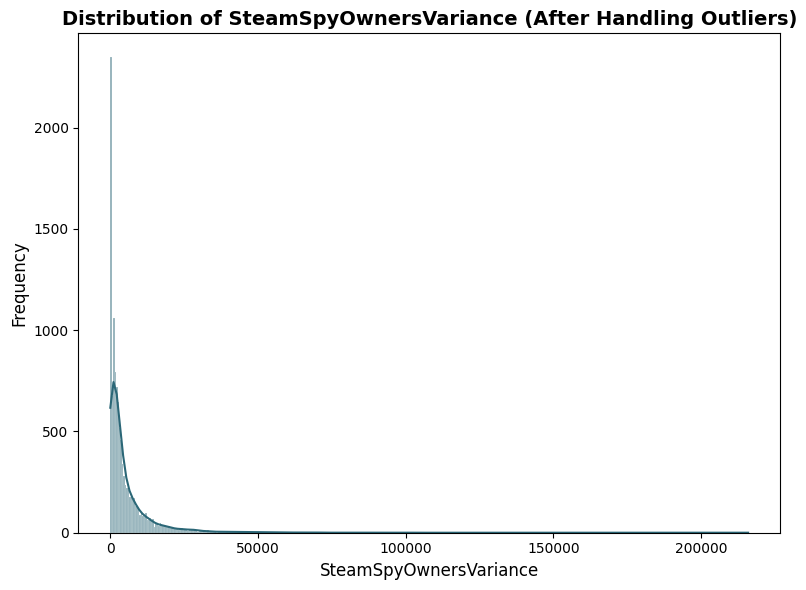

In [54]:

plt.figure(figsize=(8, 6))  
sns.histplot(df['SteamSpyOwnersVariance'].dropna(), kde=True, color='#2b6777', edgecolor='white')
plt.title('Distribution of SteamSpyOwnersVariance (After Handling Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('SteamSpyOwnersVariance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


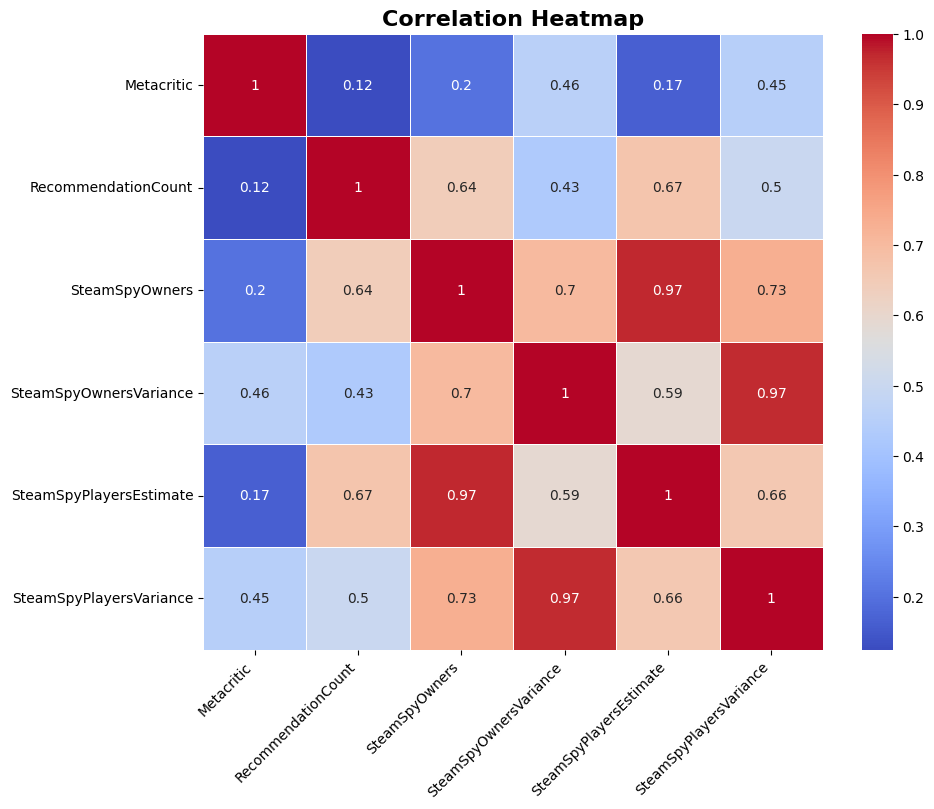

In [55]:
#correlation heatmap before handling the variance columns


plt.figure(figsize=(10, 8))
sns.heatmap(df[col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

In [ ]:


#handling sekwness
for c in col:
    df[c]=np.log1p(df[c])

condition=[df['AchievementHighlightedCount']==0,
           df['AchievementHighlightedCount']==10,
           ]
choice=[0,2]
#handling skewness
for c in col:
    df[c] = np.log1p(df[c])

condition = [df['AchievementHighlightedCount'] == 0,
             df['AchievementHighlightedCount'] == 10]
choice = [0, 2]
df['AchievementHighlightedCountt'] = np.select(condition, choice, default=1)

df['IS_AchievementHighlightedCount'] = np.where(df['AchievementHighlightedCount'] == 10, 1, 0)

#new features
df['relative_variation_owners'] = df['SteamSpyOwnersVariance'] / df['SteamSpyOwners']

df['IS_AchievementHighlightedCount']=np.select(df['AchievementHighlightedCount']==10,1,default=0)

#new features
df['relative_variation_owners']=df['SteamSpyOwnersVariance']/df['SteamSpyOwners']



TypeError: 'int' object is not iterable

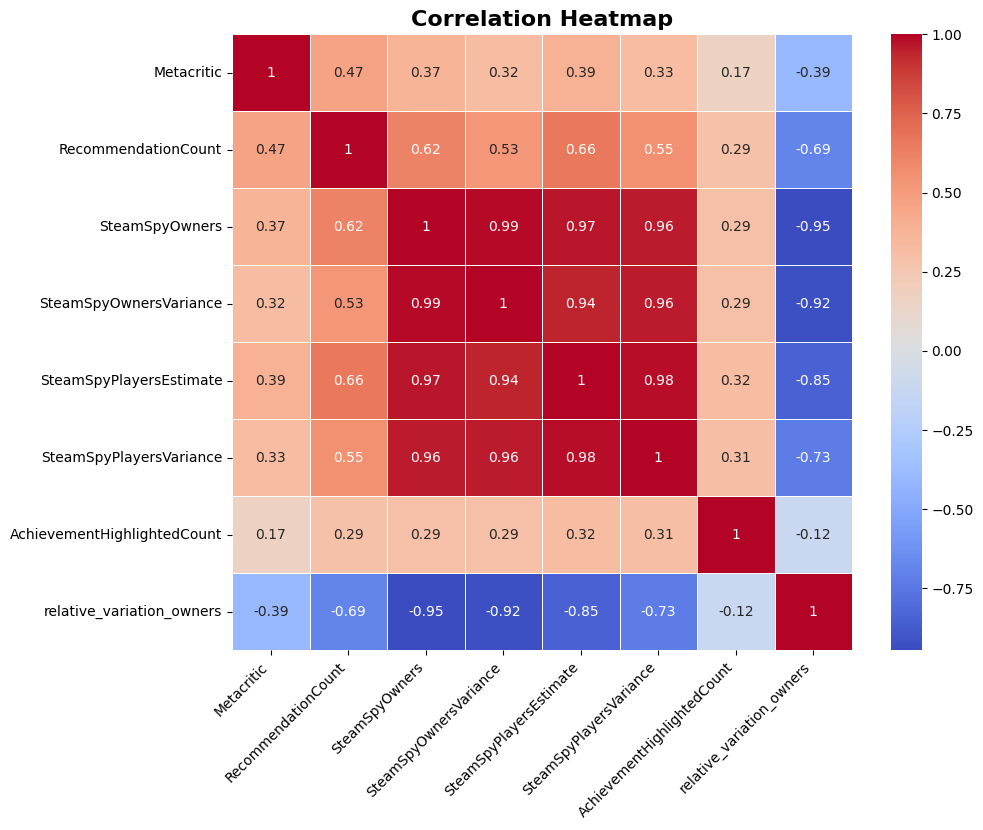

In [ ]:
#correlation heatmap after handling the variance columns
colms=['Metacritic','RecommendationCount','SteamSpyOwners','SteamSpyOwnersVariance',
     'SteamSpyPlayersEstimate','SteamSpyPlayersVariance','AchievementHighlightedCount','IS_AchievementHighlightedCount'
     'relative_variation_owners']
plt.figure(figsize=(10, 8))
sns.heatmap(df[colms].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

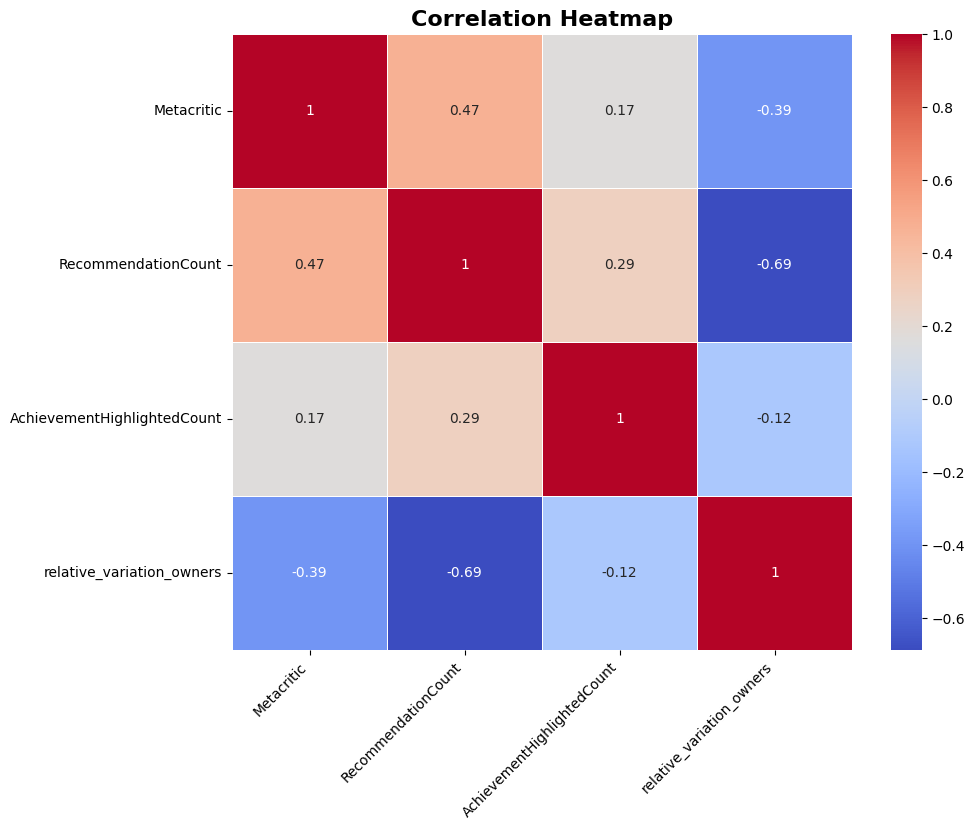

In [ ]:

df.drop(['SteamSpyOwnersVariance','SteamSpyOwners','SteamSpyPlayersEstimate','SteamSpyPlayersVariance'],axis=1,inplace=True)

colms=['Metacritic','RecommendationCount','AchievementHighlightedCount','relative_variation_owners']
plt.figure(figsize=(10, 8)) 
sns.heatmap(df[colms].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


In [ ]:
from sklearn.metrics import confusion_matrix

def train_and_evaluate_rf(x_train, y_train, x_test, y_test):
    # 1. Scaling
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    # 2. Model Training
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_model.fit(x_train_scaled, y_train)
    
    # 3. Predictions (Log values)
    y_pred = rf_model.predict(x_test_scaled)
    
    # 4. Metrics calculation (on Log scale)
    r2 = r2_score(y_test, y_pred)
    
    # 5. Metrics on Original scale (Best for discussion)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    mae_real = mean_absolute_error(y_test_orig, y_pred_orig)
    
    print(f"--- Model Results ---")
    print(f"R2 Score (Log Scale): {r2:.4f}")
    print(f"Real MAE (Actual Units): {mae_real:.2f} Recommendations")
    #confusion matrix
    cm = confusion_matrix(y_test_orig, y_pred_orig)
    print(f"Confusion Matrix:\n{cm}")
                    

In [ ]:
features = ['Metacritic', 'AchievementHighlightedCount', 'relative_variation_owners']
target= 'RecommendationCount'
x_train, x_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)
features = ['Metacritic', 'AchievementHighlightedCount', 'relative_variation_owners']
target= 'RecommendationCount'
x_train, x_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(x_train_scaled, y_train)

y_pred = rf_model.predict(x_test_scaled)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Results ---")
print(f"R2 Score (Log Scale): {r2:.4f}")

    

--- Model Results ---
R2 Score (Log Scale): 0.6594
